# Individuell inlämningsuppgift – Machine Learning

### Spår B – Klassificering (identifiera “högpris-områden”)

 `Alexander Ahl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold, cross_val_score

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,make_scorer, ConfusionMatrixDisplay,
    classification_report
)

sns.set_style("whitegrid")

housing = pd.read_csv("Data/housing.csv")

# EDA

In [2]:
print(f"Datasetets form: {housing.shape}\n")
print(f"{housing.info()}\n")
print("-------------------------------\n")

missing = housing.isnull().sum()
print("Saknade värden per kolumn:")
print(f"{missing[missing > 0]}\n")

print("Andel saknade värden ( > 0 %):")
print((housing.isnull().mean() * 100).round(1)[lambda x: x > 0], "\n")

housing.describe()

Datasetets form: (20640, 10)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

-------------------------------

Saknade värden per kolumn:
total_bedrooms    207
dtype: int64

Andel saknade värden ( > 0 %):
total_bedrooms    1.0
dtype: float64 



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Missing values
Vi ser att det enbart saknas data i kolumnen "total_bedrooms", där runt 1% saknas. Jag kommer hantera dessa tomma värden genom att fylla de med medianen för 'total_bedrooms' i min pipeline, för en enkel och säker lösning som påverkar resultatet så lite som möjligt, där t.ex. inte potentiellt extrema outliers har nån inverkan som det kan ha vid medelvärde.

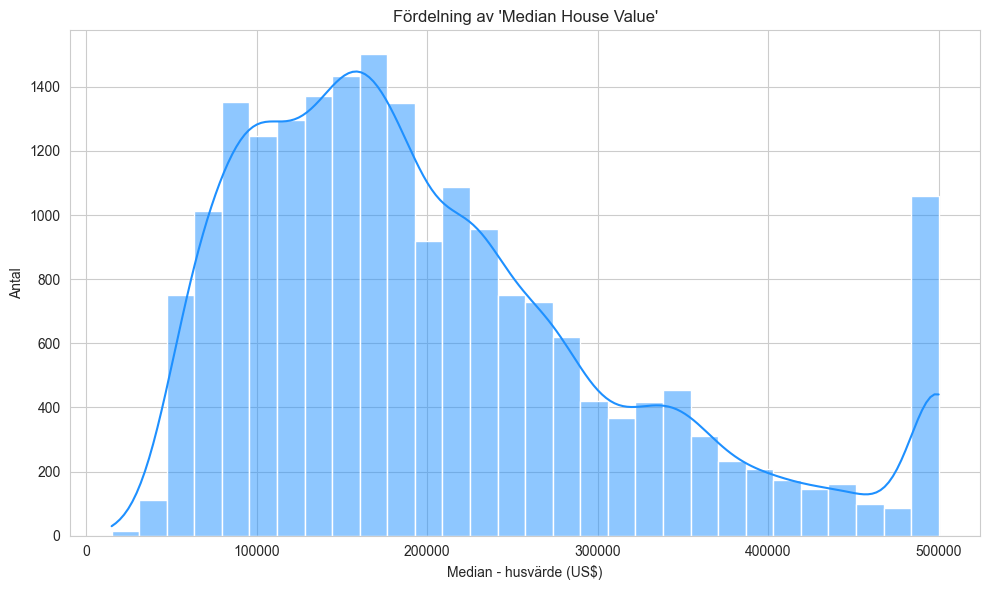

5253    500001.0
5254    500001.0
5255    500001.0
5256    500001.0
5257    500001.0
Name: median_house_value, dtype: float64

Antal med exakt 500001: 965
Andel: 4.7 %


In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(housing["median_house_value"], bins=30, kde=True, color="dodgerblue")
plt.title("Fördelning av 'Median House Value'", fontsize=12)
plt.xlabel("Median - husvärde (US$)")
plt.ylabel("Antal")
plt.tight_layout()
plt.show()

display(housing["median_house_value"].sort_values(ascending=False).head(5))

print("Antal med exakt 500001:", (housing['median_house_value'] == 500001).sum())
print("Andel:", round((housing['median_house_value'] == 500001).mean() * 100, 1), "%")

Här ser vi fördelningen av 'median house value', något som sticker ut är toppen på 50001.0 USD vilket verkar vara en övre gräns som är satt. Hela 4.7% av datan har exakt detta värde. Detta kan skapa problem i våra modeller då vi inte kan fånga den egentliga variationen och mer exakt data på dessa hus. Då det inte rör sig om mer än 4.7% kommer jag behålla det som det är, med risk att det påverkar resultatet något.

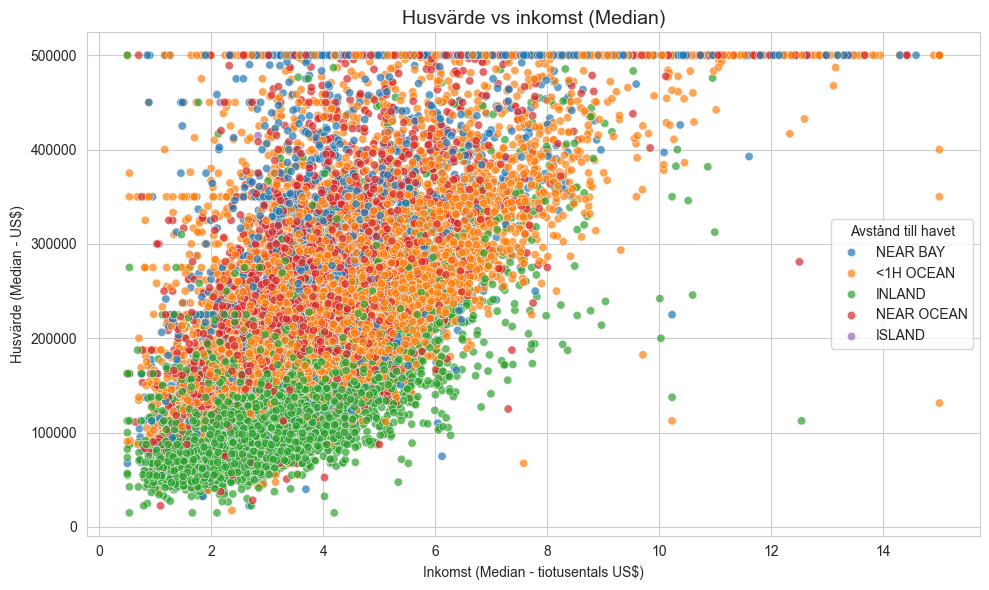

Genomsnittligt husvärde(US$) per kategori:
ocean_proximity
ISLAND        380440.0
NEAR BAY      259212.0
NEAR OCEAN    249434.0
<1H OCEAN     240084.0
INLAND        124805.0
Name: median_house_value, dtype: float64


In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=housing,
    x="median_income",
    y="median_house_value",
    hue="ocean_proximity",
    alpha=0.7
)
plt.title("Husvärde vs inkomst (Median)", fontsize=14)
plt.xlabel("Inkomst (Median - tiotusentals US$)")
plt.ylabel("Husvärde (Median - US$)")
plt.legend(title="Avstånd till havet")
plt.tight_layout()
plt.show()

print("Genomsnittligt husvärde(US$) per kategori:")
print(housing.groupby("ocean_proximity")["median_house_value"].mean().round(0).sort_values(ascending=False))

Vi ser att husen som ligger inom kategorin "Inland" har lägre husvärde samt lägre inkomst. Motsatsen gäller för kategorier som ligger närmre havet, speciellt de som ligger inom kategorin "Island", "Near bay" och "Near Ocean". Återigen ser vi att den övre gränsen på husvärde syns tydligt i plotten.

# Spår B – Klassificering (identifiera “högpris-områden”)

In [5]:
# Skapar en ny kolumn 'high_value' baserat på 'median_house_value', där topp 20% av husen klassificeras som högvärdiga (1) och resten som lågvärdiga (0)

threshold = housing['median_house_value'].quantile(0.80)
housing_high_value = housing.copy()
housing_high_value['high_value'] = (housing['median_house_value'] >= threshold).astype(int)
print(f"Tröskelvärde (80%): {threshold:.2f} US$")
print(f"Antal högvärdiga hus: {housing_high_value['high_value'].sum()}")
print(f"Andel högvärdiga hus: {housing_high_value['high_value'].mean() * 100:.1f} %")

Tröskelvärde (80%): 290000.00 US$
Antal högvärdiga hus: 4130
Andel högvärdiga hus: 20.0 %


In [9]:
# Förbereder data för modellering, där 'X' innehåller alla features förutom target('median_house_value' & 'high_value') samt y blir vårt target.

X = housing_high_value.drop(columns=['median_house_value', 'high_value'])
y = housing_high_value['high_value']

In [ ]:
# Delar upp data i tränings- och testset (80% träning, 20% test), med stratifiering baserat på 'high_value' för att bibehålla samma proportioner av klasser i båda seten.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Träningsdata:', X_train.shape, '\nTestdata:', X_test.shape)
print("\nFördelning (train) -", y_train.value_counts(normalize=True).round(3))
print("\nFördelning (test) -", y_test.value_counts(normalize=True).round(3))

Träningsdata: (16512, 9) 
Testdata: (4128, 9)

Fördelning (train) - high_value
0    0.8
1    0.2
Name: proportion, dtype: float64

Fördelning (test) - high_value
0    0.8
1    0.2
Name: proportion, dtype: float64


In [11]:
num_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_features = ['ocean_proximity']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop="first",
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ],
    remainder="drop"
)

### Baseline

In [20]:
baseline_freq = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])
baseline_freq.fit(X_train, y_train)
y_pred_baseline_freq = baseline_freq.predict(X_train)

print("DummyClassifier baseline (Gissar alltid majoritetsklass, dvs 0 i detta fall)")
print("Accuracy :", f"{accuracy_score(y_train, y_pred_baseline_freq):.4f}")
print("Precision:", f"{precision_score(y_train, y_pred_baseline_freq, zero_division=0):.4f}")
print("Recall   :", f"{recall_score(y_train, y_pred_baseline_freq, zero_division=0):.4f}")
print("F1       :", f"{f1_score(y_train, y_pred_baseline_freq, zero_division=0):.4f}")

baseline_uni = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="uniform"))
])
baseline_uni.fit(X_train, y_train)
y_pred_baseline_uni = baseline_uni.predict(X_train)

print("DummyClassifier baseline (Gissar slumpmässigt, runt 50/50)")
print("Accuracy :", f"{accuracy_score(y_train, y_pred_baseline_uni):.4f}")
print("Precision:", f"{precision_score(y_train, y_pred_baseline_uni, zero_division=0):.4f}")

print("Recall   :", f"{recall_score(y_train, y_pred_baseline_uni, zero_division=0):.4f}")
print("F1       :", f"{f1_score(y_train, y_pred_baseline_uni, zero_division=0):.4f}")

DummyClassifier baseline (Gissar alltid majoritetsklass, dvs 0 i detta fall)
Accuracy : 0.7999
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000
DummyClassifier baseline (Gissar slumpmässigt, runt 50/50)
Accuracy : 0.4970
Precision: 0.1974
Recall   : 0.4936
F1       : 0.2820


### Tränar modeller

In [21]:
logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42,
        class_weight='balanced'
    ))
])

tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

models = {
    "LogisticRegression": logreg,
    "DecisionTree": tree,
    "RandomForest": rf
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print("Tränade:", name)


Tränade: LogisticRegression
Tränade: DecisionTree
Tränade: RandomForest


### Cross-validation

In [24]:
cross_val = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train, y_train,
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring = ['accuracy', 'precision', 'recall', 'f1'],
        n_jobs = -1,
        return_train_score = False
    )
    
    cross_val[name] = scores

summary_cross_val = pd.DataFrame({
    name: {
        "Accuracy":scores['test_accuracy'].mean(),
        "Precision":scores['test_precision'].mean(),
        "Recall":scores['test_recall'].mean(),
        "F1":scores['test_f1'].mean(),
    }
    for name, scores in cross_val.items()
}).T.round(4)

print("Cross-validation sammanfattning (medelvärden):")
display(summary_cross_val.sort_values('F1', ascending=False))



Cross-validation sammanfattning (medelvärden):


,Accuracy,Precision,Recall,F1
RandomForest,0.9215,0.8862,0.6970,0.7802
DecisionTree,0.8874,0.7252,0.7037,0.7142
LogisticRegression,0.8312,0.5496,0.8656,0.6723


För att balansera precision och recall, där båda är viktiga för resultatet, så har jag valt att bestämma modell efter högst F1-score. Att enbart gå på precision och offra recall gör att vi missar för många högprisområden, medan att enbart satsa på hög recall kommer ge oss betydligt sämre precision, och därmed fler falska positiva, för många områden kommer klassas som högprisområden som inte är det. Ett balanserat mått mellan de två ger oss bäst förutsättning för ett team att snabbt få fram vilket typ av område det är.

### Bästa modell - GridSearch

In [34]:
best_model_name = summary_cross_val['F1'].idxmax()
best_model = models[best_model_name]
print(f"Bästa modell baserat på högst F1: {best_model_name}\n")

param_grid = {
    'model__n_estimators':[65, 70, 75],
    'model__max_depth':[18, 20, 22, None],
    'model__min_samples_split':[8, 10],
    'model__min_samples_leaf':[2, 3],
    'model__class_weight':['balanced', {0:1, 1:6}]
}

grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\nBästa parametrar:")
print(grid_search.best_params_)
print(f"\nBästa F1: {grid_search.best_score_:.4f}")

Bästa modell baserat på högst F1: RandomForest

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Bästa parametrar:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 3, 'model__min_samples_split': 8, 'model__n_estimators': 70}

Bästa F1: 0.7949


Jag valde min modell baserat på bästa F1-resultatet efter min Cross-Validation för att få en balans mellan recall och precision. Jag optimerade parametrarna för n_estimators, max_depth, min_samples_split, min_samples_leaf och class_weight då bästa modellen blev RandomForest. Då datan var starkt obalanserad(80/20) hade class_weight stor inverkan på resultatet, där modellen straffas hårdare om den tar fel på klass=1.

### Sluttest för bästa modellen

In [54]:
final_model = grid_search.best_estimator_

y_pred_test = final_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Lågvärdigt (0)', 'Högvärdigt (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

Lågvärdigt (0)       0.94      0.95      0.95      3302
Högvärdigt (1)       0.79      0.77      0.78       826

      accuracy                           0.91      4128
     macro avg       0.87      0.86      0.86      4128
  weighted avg       0.91      0.91      0.91      4128



### Utvärdering av vald modell på test-data

In [55]:
def evaluate_on_test(
        model, model_name,
        X_test, y_test,
        target_names=("Lågvärdigt (0)", "Högvärdigt (1)")
    ):
    """
    Utvärderar modell på testdata.
    """
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)


    print(f"\n{'─'*40}\n")
    print(f"{model_name} - TEST")
    print(f"\n{'─'*40}\n")
    print(f"Accuracy  : {acc:.4f}    → Hur stor andel av alla områden modellen gissade rätt på")
    print(f"Precision : {prec:.4f}    → Hur många av de som modellen kallade högvärdiga som faktiskt var det")
    print(f"Recall    : {rec:.4f}    → Hur stor andel av de faktiska högvärdiga områdena modellen hittade")
    print(f"F1        : {f1:.4f}    → Bra mått när både precision och recall är viktiga\n")


    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot()
    plt.grid(False)
    plt.title(f"Confusion matrix - {model_name} (TEST)")
    plt.show()
    

    return { "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm }


────────────────────────────────────────

RandomForest - TEST

────────────────────────────────────────

Accuracy  : 0.9130    → Hur stor andel av alla områden modellen gissade rätt på
Precision : 0.7879    → Hur många av de som modellen kallade högvärdiga som faktiskt var det
Recall    : 0.7736    → Hur stor andel av de faktiska högvärdiga områdena modellen hittade
F1        : 0.7807    → Bra mått när både precision och recall är viktiga



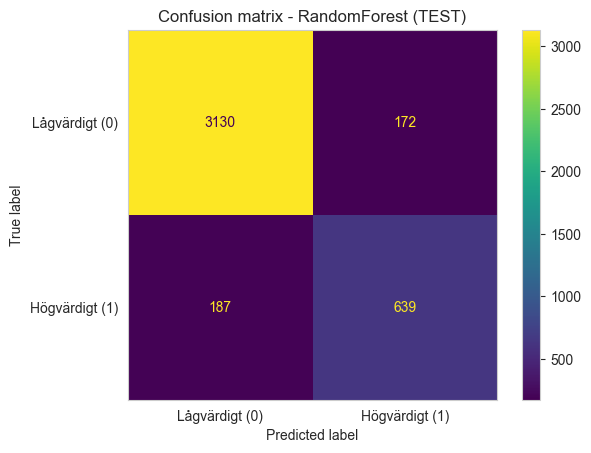

In [56]:
test_results = {}

test_results[best_model_name] = evaluate_on_test(model=final_model, model_name=best_model_name, X_test=X_test, y_test=y_test)

summary_table = pd.DataFrame({
    name: {
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"]
    }
    for name, res in test_results.items()
}).T

### Jämför mot baseline

In [57]:
y_pred_baseline_freq_test = baseline_freq.predict(X_test)
y_pred_baseline_uni_test = baseline_uni.predict(X_test)

predictions = {
    "RandomForest (Optimerad)": y_pred_test,
    "Baseline (Most Frequent)": y_pred_baseline_freq_test,
    "Baseline (Uniform)": y_pred_baseline_uni_test,
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
data = {}

for name, y_pred in predictions.items():
    data[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]

comparison_df = pd.DataFrame(data, index=metrics).T.round(4)

print("\nJämförelse mellan baseline-modeller och RandomForest (Optimerad) på test-setet:")
display(comparison_df.sort_values("F1-score", ascending=False))


Jämförelse mellan baseline-modeller och RandomForest (Optimerad) på test-setet:


,Accuracy,Precision,Recall,F1-score
RandomForest (Optimerad),0.9130,0.7879,0.7736,0.7807
Baseline (Uniform),0.4879,0.1925,0.4879,0.2760
Baseline (Most Frequent),0.7999,0.0000,0.0000,0.0000


Vår valda modell är betydligt bättre än baseline-modellerna, vilket gör att vår modell faktiskt är användbar för kunden. Resultatet visar på en rätt hög precision, i nästan 79% av fallena som den säger ligger i top 20% så har modellen rätt. Samma med recall, den fångar 77% av alla verkliga högprisområden(missar 23%). Detta ger ett balanserat F1-score på 0.78, ett liknande mått som på träningsdatan vilket tyder på en stabil modell. Detta är den modellen som jag skulle rekommendera till kunden.